In [24]:
# integration du notebook kaggle et aggregations avec les variables des autres fichiers

import os
import re
import numpy as np
import pandas as pd
import gc
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE


import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

import matplotlib.pyplot as plt
import seaborn as sns
import pickle

import mlflow
import mlflow.sklearn

print(" Imports terminés")

 Imports terminés


In [4]:
# optimisation de la RAM pour éviter les erreurs de mémoire
def reduce_mem_usage(df, verbose=True):
    """Réduit l'usage mémoire en convertissant les types de données"""
    start_mem = df.memory_usage().sum() / 1024**2
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float32)
    
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f'Mémoire réduite de {start_mem:.2f} MB à {end_mem:.2f} MB ({100 * (start_mem - end_mem) / start_mem:.1f}% reduction)')
    
    return df

In [5]:
# bureau et bureau_balance
with open("bureau_agg.pkl", "rb") as f:
    bureau_agg = pickle.load(f)

gc.collect()

0

In [6]:
# Credit CARD 
with open("credit_card_client.pkl", "rb") as f:
    credit_card_client = pickle.load(f)

gc.collect()

0

In [7]:
# INSTALLMENTS
with open("installments_agg.pkl", "rb") as f: 
    installments_agg = pickle.load(f)

gc.collect()

0

In [8]:
# Previous Application 

with open('prev_agg.pkl', 'rb') as f:
    prev_agg = pickle.load(f)
    
gc.collect()

0

In [9]:
# POS_CASH 

with open('pos_agg.pkl', 'rb') as f:
    pos_agg = pickle.load(f)

gc.collect()

0

In [10]:
# application_train

with open("app_train_domain.pkl", "rb") as f:
    app_train_domain = pickle.load(f)

# application_test
with open("app_test_domain.pkl", "rb") as f:
    app_test_domain = pickle.load(f)

gc.collect()    

0

In [11]:
# Fusion progressive de toutes les tables sur SK_ID_CURR
print("Début de la fusion...")

# Partir de app_train_domain
train = app_train_domain.copy()


print(f"Train initial: {train.shape}")

# Fusion avec Bureau
train = train.merge(bureau_agg, on='SK_ID_CURR', how='left')

print(f"Après bureau: {train.shape}")

# Fusion avec Credit Card 
train = train.merge(credit_card_client, on='SK_ID_CURR', how='left')

print(f"Après credit: {train.shape}")



# Fusion avec Installments:
## Charger la correspondance SK_ID_PREV avec SK_ID_CURR de previous_application
## chargement des données depuis la racine du projet
data_dir = 'data/' 
prev_link = pd.read_csv(data_dir + 'previous_application.csv',
                        usecols=['SK_ID_CURR', 'SK_ID_PREV'])
prev_link = reduce_mem_usage(prev_link)

## Fusionner installments_agg avec la correspondance
installments_with_curr = prev_link.merge(
    installments_agg,
    on='SK_ID_PREV',
    how='left'
)
## Agréger au niveau client (SK_ID_CURR)
installments_agg = (installments_with_curr
                     .drop('SK_ID_PREV', axis=1)
                     .groupby('SK_ID_CURR')
                     .agg(['mean', 'max', 'min', 'sum']))

installments_agg.columns = ['INSTAL_' + '_'.join(col).upper()
                              for col in installments_agg.columns]
installments_agg.reset_index(inplace=True)

print(f"\n installments_agg shape: {installments_agg.shape}")

train = train.merge(installments_agg, on='SK_ID_CURR', how='left')

print(f"Après installments: {train.shape}")



# Fusion avec Previous Application
train = train.merge(prev_agg, on='SK_ID_CURR', how='left')

print(f"Après previous: {train.shape}")

# Fusion avec POS_CASH
train = train.merge(pos_agg, on='SK_ID_CURR', how='left')

print(f"Après POS_CASH: {train.shape}")

print("\n Toutes les fusions terminées ")
print(f"\n Shape finale TRAIN: {train.shape}")

Début de la fusion...
Train initial: (307511, 245)
Après bureau: (307511, 449)
Après credit: (307511, 558)
Mémoire réduite de 25.49 MB à 12.74 MB (50.0% reduction)

 installments_agg shape: (338857, 97)
Après installments: (307511, 654)
Après previous: (307511, 872)
Après POS_CASH: (307511, 894)

 Toutes les fusions terminées 

 Shape finale TRAIN: (307511, 894)


Top 15 features positivement corrélées avec TARGET:
TARGET                                             1.000000
CC_CLIENT_CC_CNT_DRAWINGS_ATM_CURRENT_MEAN_SUM     0.118044
CC_CLIENT_CC_CNT_DRAWINGS_ATM_CURRENT_MEAN_MEAN    0.118043
CC_CLIENT_CC_CNT_DRAWINGS_ATM_CURRENT_MEAN_MAX     0.118015
CC_CLIENT_CC_CNT_DRAWINGS_ATM_CURRENT_MEAN_MIN     0.117719
bureau_DAYS_CREDIT_MEAN                            0.089729
CC_CLIENT_CC_AMT_BALANCE_MEAN_SUM                  0.087657
CC_CLIENT_CC_AMT_BALANCE_MEAN_MAX                  0.087617
CC_CLIENT_CC_AMT_BALANCE_MEAN_MEAN                 0.087365
CC_CLIENT_CC_AMT_BALANCE_MEAN_MIN                  0.086997
PREV_NAME_CONTRACT_STATUS_REFUSED_MEAN             0.077671
CC_CLIENT_CC_AMT_DRAWINGS_ATM_CURRENT_MEAN_MEAN    0.077126
CC_CLIENT_CC_AMT_DRAWINGS_ATM_CURRENT_MEAN_MIN     0.077065
CC_CLIENT_CC_AMT_DRAWINGS_ATM_CURRENT_MEAN_SUM     0.076954
CC_CLIENT_CC_AMT_DRAWINGS_ATM_CURRENT_MEAN_MAX     0.076879
Name: TARGET, dtype: float64

Top 15 features né

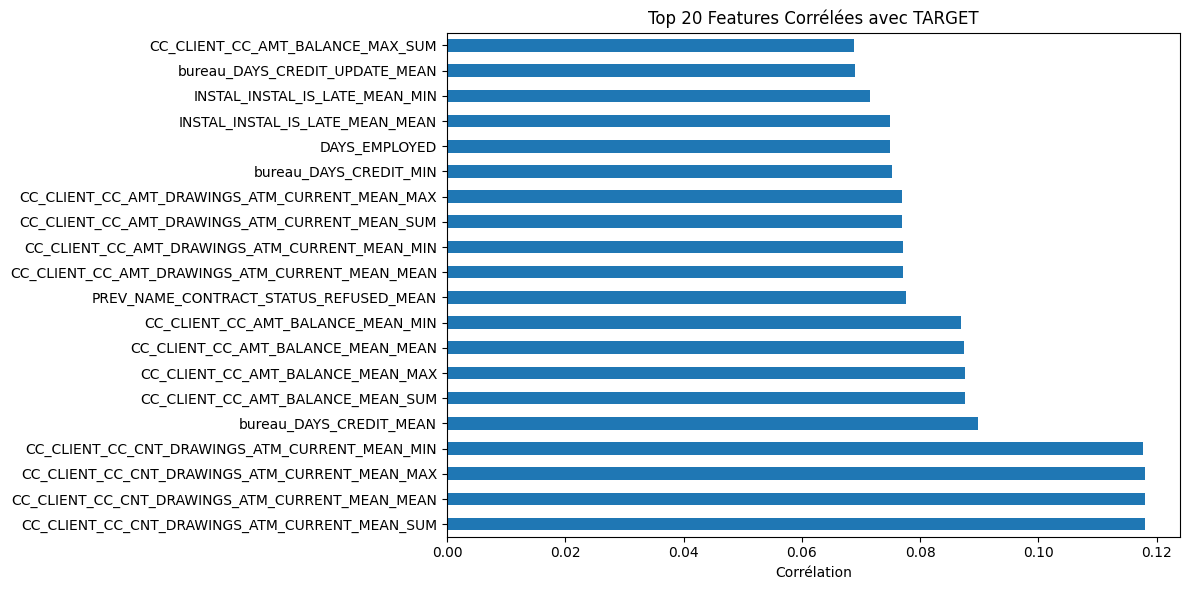

In [12]:
# Calculer les corrélations avec la TARGET
correlations = train.corr()['TARGET'].sort_values(ascending=False)

print("Top 15 features positivement corrélées avec TARGET:")
print(correlations.head(15))

print("\nTop 15 features négativement corrélées avec TARGET:")
print(correlations.tail(15))

# Visualisation
plt.figure(figsize=(12, 6))
correlations.drop('TARGET').head(20).plot.barh()
plt.title('Top 20 Features Corrélées avec TARGET')
plt.xlabel('Corrélation')
plt.tight_layout()
plt.show()

In [13]:
# vérification de y
y=train['TARGET']
print("\n1️ Vérification de y (TARGET):")
print(f"   Type: {y.dtype}")
print(f"   Valeurs uniques: {y.unique()}")
print(f"   Distribution: \n{y.value_counts()}")

# si y est déjà en 0/1, pas besoin d'encoder
if set(y.unique()) == {0, 1}:
    print("    y est déjà encodé en 0/1")
else:
    print("    y n'est pas en 0/1, encodage nécessaire")


1️ Vérification de y (TARGET):
   Type: int64
   Valeurs uniques: [1 0]
   Distribution: 
TARGET
0    282686
1     24825
Name: count, dtype: int64
    y est déjà encodé en 0/1


In [14]:
# Préparer et séparer features X et target y

train_clean = app_train_domain.dropna(subset=['TARGET']).copy()

X = train_clean.drop(columns=['TARGET', 'SK_ID_CURR']).fillna(-999)
y = train_clean['TARGET'].astype(int)  # Déjà 0/1

# Test : utiliser app_test_domain
X_test = app_test_domain.drop(columns=['SK_ID_CURR'], errors='ignore').fillna(-999)

# Aligner les colonnes
X, X_test = X.align(X_test, join='inner', axis=1)

print(f"\n Préparation OK:")
print(f"   X:      {X.shape}")
print(f"   y:      {y.shape}  |  valeurs: {sorted(y.unique())}")
print(f"   X_test: {X_test.shape}")
print(f"   NaN dans y: {y.isnull().sum()}")
print(f"   Distribution y: {y.value_counts().to_dict()}")

# Split stratifié
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n Split OK:")
print(f"   X_train: {X_train.shape}  |  défauts: {y_train.mean():.2%}")
print(f"   X_val:   {X_val.shape}    |  défauts: {y_val.mean():.2%}")
print(f"   X_test:  {X_test.shape}")


print("\n Données prêtes pour la modélisation")


 Préparation OK:
   X:      (307511, 239)
   y:      (307511,)  |  valeurs: [np.int64(0), np.int64(1)]
   X_test: (48744, 239)
   NaN dans y: 0
   Distribution y: {0: 282686, 1: 24825}

 Split OK:
   X_train: (246008, 239)  |  défauts: 8.07%
   X_val:   (61503, 239)    |  défauts: 8.07%
   X_test:  (48744, 239)

 Données prêtes pour la modélisation


In [ ]:
mlflow.set_experiment("Home_Credit_Default_Risk")


In [15]:
# Class weight

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print(f"\nPoids calculés: {class_weight_dict}")
print(f"  La classe minoritaire (1) a un poids ~{class_weights[1]/class_weights[0]:.1f}x plus élevé")



Poids calculés: {0: np.float64(0.5439092983356032), 1: np.float64(6.193554884189325)}
  La classe minoritaire (1) a un poids ~11.4x plus élevé


In [16]:
# Regression logistique avec class weight

lr_weighted = LogisticRegression(
    max_iter=500, 
    random_state=42, 
    class_weight='balanced',  # Automatique
    solver='liblinear'
)
lr_weighted.fit(X_train, y_train)
y_val_pred_lr_w = lr_weighted.predict_proba(X_val)[:, 1]
auc_lr_w = roc_auc_score(y_val, y_val_pred_lr_w)
print(f"   ROC AUC: {auc_lr_w:.4f}")

   ROC AUC: 0.6681


In [17]:
# Random Forest avec class_weight

rf_weighted = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    class_weight='balanced',  # Automatique
    n_jobs=-1,
    verbose=0
)
rf_weighted.fit(X_train, y_train)
y_val_pred_rf_w = rf_weighted.predict_proba(X_val)[:, 1]
auc_rf_w = roc_auc_score(y_val, y_val_pred_rf_w)
print(f"   ROC AUC: {auc_rf_w:.4f}")

   ROC AUC: 0.7156


In [20]:
# SMOTE

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"   Avant SMOTE: {X_train.shape[0]} lignes")
print(f"   Après SMOTE: {X_train_smote.shape[0]} lignes")
print(f"\n   Distribution après SMOTE:")
print(f"     0: {(y_train_smote == 0).sum()} ({(y_train_smote == 0).mean()*100:.2f}%)")
print(f"     1: {(y_train_smote == 1).sum()} ({(y_train_smote == 1).mean()*100:.2f}%)")

   Avant SMOTE: 246008 lignes
   Après SMOTE: 452296 lignes

   Distribution après SMOTE:
     0: 226148 (50.00%)
     1: 226148 (50.00%)


In [21]:
# Logistic Regression sur données SMOTE

lr_smote = LogisticRegression(max_iter=500, random_state=42, solver='liblinear')
lr_smote.fit(X_train_smote, y_train_smote)
y_val_pred_lr_s = lr_smote.predict_proba(X_val)[:, 1]
auc_lr_s = roc_auc_score(y_val, y_val_pred_lr_s)
print(f"   ROC AUC: {auc_lr_s:.4f}")

   ROC AUC: 0.6365


In [22]:
# Random Forest sur données SMOTE

rf_smote = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1, verbose=0)
rf_smote.fit(X_train_smote, y_train_smote)
y_val_pred_rf_s = rf_smote.predict_proba(X_val)[:, 1]
auc_rf_s = roc_auc_score(y_val, y_val_pred_rf_s)
print(f"   ROC AUC: {auc_rf_s:.4f}")

   ROC AUC: 0.6569


In [25]:
# Nettoyer les noms de colonnes car lightgbm ne supporte pas certains caracteres JSON

def clean_column_names(df):
    """Nettoie les noms de colonnes pour LightGBM"""
    new_columns = []
    for col in df.columns:
        # Remplacer les caractères spéciaux par des underscores
        col_clean = re.sub(r'[^A-Za-z0-9_]', '_', str(col))
        # Éviter les underscores multiples
        col_clean = re.sub(r'_+', '_', col_clean)
        # Enlever les underscores au début et à la fin
        col_clean = col_clean.strip('_')
        new_columns.append(col_clean)
    
    df.columns = new_columns
    return df

In [26]:
# application du nettoyage des colonnes
print(f"Avant: {X_train.columns[:5].tolist()} ...")

X_train = clean_column_names(X_train)
X_val = clean_column_names(X_val)
X_test = clean_column_names(X_test)

print(f"Après: {X_train.columns[:5].tolist()} ...")

# Vérifier qu'il n'y a plus de doublons
if X_train.columns.duplicated().any():
    print("⚠️ Attention: colonnes dupliquées détectées")
    # Ajouter un suffixe aux colonnes dupliquées
    X_train.columns = pd.io.common.dedup_names(X_train.columns, is_potential_multiindex=False)
    X_val.columns = X_train.columns
    X_test.columns = X_train.columns
    print(" Colonnes dupliquées renommées")

print(f"\n Nettoyage terminé")
print(f"   Nombre de colonnes: {len(X_train.columns)}")

Avant: ['NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL'] ...
Après: ['NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL'] ...

 Nettoyage terminé
   Nombre de colonnes: 239


In [27]:
# LightGBM avec scale_pos_weight

 
# Calculer le ratio de déséquilibre
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"   scale_pos_weight: {scale_pos_weight:.2f}")
    
lgb_params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'num_leaves': 15,
        'max_depth': 5,
        'learning_rate': 0.05,
        'scale_pos_weight': scale_pos_weight,  # Gère le déséquilibre
        'verbose': -1
    }
    
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_train)
    
model_lgb = lgb.train(
        lgb_params, 
        lgb_train, 
        num_boost_round=100,
        valid_sets=[lgb_val],
        callbacks=[lgb.early_stopping(stopping_rounds=10), lgb.log_evaluation(period=0)]
    )
    
y_val_pred_lgb = model_lgb.predict(X_val)
auc_lgb = roc_auc_score(y_val, y_val_pred_lgb)
print(f"   ROC AUC: {auc_lgb:.4f}")

# Prédictions sur test
y_test_pred_lgb = model_lgb.predict(X_test)

print(" LightGBM terminé")


   scale_pos_weight: 11.39
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's auc: 0.753358
   ROC AUC: 0.7534
 LightGBM terminé


In [28]:
# XGBoost avec scale_pos_weight

scale_pos_weight_xgb = (y_train == 0).sum() / (y_train == 1).sum()
print(f"   scale_pos_weight: {scale_pos_weight_xgb:.2f}")
    
xgb_params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'max_depth': 5,
        'learning_rate': 0.05,
        'scale_pos_weight': scale_pos_weight_xgb,  # Gère le déséquilibre
        'verbosity': 0
    }
    
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
    
model_xgb = xgb.train(
        xgb_params,
        dtrain,
        num_boost_round=100,
        evals=[(dval, 'validation')],
        early_stopping_rounds=10,
        verbose_eval=False
    )
    
y_val_pred_xgb = model_xgb.predict(dval)
auc_xgb = roc_auc_score(y_val, y_val_pred_xgb)
print(f"   ROC AUC: {auc_xgb:.4f}")


   scale_pos_weight: 11.39
   ROC AUC: 0.7528


In [29]:
# CatBoost avec auto_class_weights
  
cat = CatBoostClassifier(
        iterations=100,
        depth=5,
        learning_rate=0.1,
        auto_class_weights='Balanced',  # Gère automatiquement
        random_seed=42,
        verbose=0
    )
    
cat.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=10, verbose=0)
    
y_val_pred_cat = cat.predict_proba(X_val)[:, 1]
auc_cat = roc_auc_score(y_val, y_val_pred_cat)
print(f"   ROC AUC: {auc_cat:.4f}")

   ROC AUC: 0.7538


In [31]:
# results summary

results = {
    'LR (class_weight)': auc_lr_w,
    'RF (class_weight)': auc_rf_w,
    'LR (SMOTE)': auc_lr_s,
    'RF (SMOTE)': auc_rf_s,
    'LightGBM (scale_pos_weight)': auc_lgb,
    'XGBoost (scale_pos_weight)': auc_xgb,
    'CatBoost (auto_class_weights)': auc_cat
}

print("\n ROC AUC sur validation set:")
for name, score in sorted(results.items(), key=lambda x: x[1] if x[1] else 0, reverse=True):
    if score is not None:
        print(f"   {name:30s}: {score:.4f}")

# Meilleur modèle
best = max([(n, s) for n, s in results.items() if s is not None], key=lambda x: x[1])
print(f"\n Meilleur modèle: {best[0]} (AUC = {best[1]:.4f})")


 ROC AUC sur validation set:
   CatBoost (auto_class_weights) : 0.7538
   LightGBM (scale_pos_weight)   : 0.7534
   XGBoost (scale_pos_weight)    : 0.7528
   RF (class_weight)             : 0.7156
   LR (class_weight)             : 0.6681
   RF (SMOTE)                    : 0.6569
   LR (SMOTE)                    : 0.6365

 Meilleur modèle: CatBoost (auto_class_weights) (AUC = 0.7538)


In [ ]:
# Sauvegarder les datasets finaux
train.to_csv('train_final.csv', index=False)
test.to_csv('test_final.csv', index=False)

# Sauvegarder les prédictions
submission_lr = pd.DataFrame({
    'SK_ID_CURR': test['SK_ID_CURR'],
    'TARGET': predictions_lr
})
submission_lr.to_csv('submission_logistic.csv', index=False)

submission_rf = pd.DataFrame({
    'SK_ID_CURR': test['SK_ID_CURR'],
    'TARGET': predictions_rf
})
submission_rf.to_csv('submission_random_forest.csv', index=False)

print(" Fichiers sauvegardés:")
print("  - train_final.csv")

print("  - submission_logistic.csv")
print("  - submission_random_forest.csv")

KeyboardInterrupt: 

In [ ]:
# Résumé du pipeline
print("RÉSUMÉ DU PIPELINE")
print(f"  - Train: {train.shape[0]} lignes x {train.shape[1]} colonnes")
print(f"  - Test: {test.shape[0]} lignes x {test.shape[1]} colonnes")
print(f"  - Features: {train.shape[1] - 2} (sans SK_ID_CURR et TARGET)")

print(f"\n Sources de données intégrées:")
print(f"  - application_train: {app_train_domain.shape[1]-1} features")
print(f"  - application_test: {app_test_domain.shape[1]-1} features")
print(f"  - bureau + bureau_balance → {bureau_agg.shape[1]-1} features")
print(f"  - credit_card {credit_card_client.shape[1]-1} features")
print(f"  - installments → {installments_agg.shape[1]-1} features")
print(f"  - previous_application → {prev_agg.shape[1]-1} features")
print(f"  - POS_CASH_balance → {pos_agg.shape[1]-1} features")

print(f"\n Performances:")
print(f"  - Logistic Regression: ROC AUC = {cv_scores.mean():.4f}")
print(f"  - Random Forest: ROC AUC = {cv_scores_rf.mean():.4f}")

print("\n Pipeline terminé")